# Reconstruction test

Re-run training from a pre-jump checkpoint for volatile, high–mean-$R^2$ cell–room pairs and compare saved vs retrained rate maps at the largest rate-map jump.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        _root = str(_path)
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

from cell_evolutions.cell_evolution_model import (
    advance_mask_generator_for_ratemap,
    build_rae,
    compute_ratemap,
    fr_loss,
    masking,
)
from cycles.cycles_data import flatten_schedule, load_manifest, load_room
from cycles.cycles_paths import INDIV_CKPT_DIR, RESULTS_DIR, ROOMS_DIR
from cycles.cycles_train import (
    CyclesConfig,
    DEFAULT_CHECKPOINT_EVERY_K_ROOMS,
    IndivCheckpointRef,
    load_indiv_checkpoint,
    rebatch_trajectories,
    resolve_indiv_checkpoint_for_resume,
)
from cycles.gaussian_fit_cycle_analysis import (
    build_cell_receptive_fields_df,
    build_truncated_segments,
    n_rooms_from_truncated_file,
    visit_to_segment,
    visits_for_cell_in_room,
)
from cycles.gaussian_fit_cycle_plots import _gaussian_evolution_cmap

GAUSSIANS_RESULTS_PATH = RESULTS_DIR / "gaussian_rf_fits.npz"
TRUNCATED_FILE_PATHS = [
    RESULTS_DIR / "cycles_ratemaps_truncated_10.npz",
    RESULTS_DIR / "cycles_ratemaps_truncated_10_20.npz",
    RESULTS_DIR / "cycles_ratemaps_truncated_20_30.npz",
]
THRESHOLD_ACTIVITY_MAX = 0.2
TOP_FRAC_MEAN_R2 = 0.30
N_SELECT = 10

for p in [GAUSSIANS_RESULTS_PATH, *TRUNCATED_FILE_PATHS]:
    assert p.is_file(), f"Missing: {p.resolve()}"

## Stage A — Gaussian-fit pool (activity + global top 30% mean $R^2$)

In [2]:
df = build_cell_receptive_fields_df(GAUSSIANS_RESULTS_PATH)

sub = df.reset_index()
g = (
    sub.groupby(["cell_idx", "room_id"], as_index=False)
    .agg(
        mean_r2=("r2", "mean"),
        mean_signal_max=("signal_max", "mean"),
        n_r2=("r2", lambda s: int(s.notna().sum())),
    )
)
g = g[g["n_r2"] >= 2]
g = g[g["mean_signal_max"] > THRESHOLD_ACTIVITY_MAX]

cutoff = g["mean_r2"].quantile(1 - TOP_FRAC_MEAN_R2)
pool = g[g["mean_r2"] >= cutoff].copy().reset_index(drop=True)
print(f"Pairs after activity filter: {len(g):,}")
print(f"Global top {TOP_FRAC_MEAN_R2:.0%} mean R² pool: {len(pool):,} (cutoff mean_r2 >= {cutoff:.4f})")
pool.head()

Pairs after activity filter: 9,173
Global top 30% mean R² pool: 2,752 (cutoff mean_r2 >= 0.9569)


,cell_idx,room_id,mean_r2,mean_signal_max,n_r2
0,0,9,0.960087,0.287709,30
1,0,15,0.974468,0.398030,30
2,1,1,0.974337,0.326096,30
3,1,2,0.984658,0.501833,30
4,1,6,0.977515,0.335058,30


## Stage B — Rate-map volatility (`delta_std`) and top 10

In [3]:
segments = build_truncated_segments(TRUNCATED_FILE_PATHS)
n_rooms = n_rooms_from_truncated_file(segments[0][2])

# Group (local_v, cell_idx, visit_idx) by truncated NPZ — same layout as collect_ratemap_requests
requests_by_path: dict[Path, list[tuple[int, int, int]]] = {}
for row in tqdm(pool.itertuples(), desc="build ratemap requests",total=len(pool)):
    visits = visits_for_cell_in_room(df, int(row.cell_idx), int(row.room_id))
    for _, vrow in visits.iterrows():
        visit_idx = int(vrow["visit_idx"])
        cell_idx = int(vrow["cell_idx"])
        path, local_v = visit_to_segment(visit_idx, segments, n_rooms)
        requests_by_path.setdefault(path, []).append((local_v, cell_idx, visit_idx))

print(f"Truncated files: {len(requests_by_path)}")
for path, items in sorted(requests_by_path.items(), key=lambda x: str(x[0])):
    print(f"  {path.name}: {len(items):,} slices")


def load_ratemaps_by_visit_tqdm(
    requests_by_path: dict[Path, list[tuple[int, int, int]]],
) -> dict[tuple[int, int], np.ndarray]:
    """Same as load_ratemaps_by_visit: one truncated NPZ at a time, then close."""
    result: dict[tuple[int, int], np.ndarray] = {}
    for path in tqdm(sorted(requests_by_path, key=lambda p: str(p)), desc="load ratemaps"):
        items = requests_by_path[path]
        with np.load(path, mmap_mode="r") as data:
            ratemaps = data["ratemaps"]
            for local_v, cell_idx, visit_idx in items:
                result[(visit_idx, cell_idx)] = np.asarray(
                    ratemaps[local_v, cell_idx]
                ).copy()
    return result


ratemaps_by_visit = load_ratemaps_by_visit_tqdm(requests_by_path)
print(f"Loaded {len(ratemaps_by_visit):,} rate-map slices")
del requests_by_path

build ratemap requests:   0%|          | 0/2752 [00:00<?, ?it/s]

Truncated files: 3
  cycles_ratemaps_truncated_10.npz: 27,520 slices
  cycles_ratemaps_truncated_10_20.npz: 27,520 slices
  cycles_ratemaps_truncated_20_30.npz: 27,520 slices


load ratemaps:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded 82,560 rate-map slices


In [4]:
def ratemap_delta_stats(cell_idx: int, room_id: int) -> dict | None:
    """Consecutive-cycle mean |Δratemap| and their std (delta_std)."""
    visits = visits_for_cell_in_room(df, cell_idx, room_id)
    if len(visits) < 2:
        return None
    rms = []
    for _, vrow in visits.iterrows():
        key = (int(vrow["visit_idx"]), int(vrow["cell_idx"]))
        rm = ratemaps_by_visit.get(key)
        if rm is None:
            return None
        rms.append(np.asarray(rm, dtype=np.float64))
    mean_deltas = [
        float(np.nanmean(np.abs(rms[k + 1] - rms[k])))
        for k in range(len(rms) - 1)
    ]
    return {
        "mean_deltas": mean_deltas,
        "delta_std": float(np.std(mean_deltas, ddof=0)),
    }


rows = []
for row in tqdm(pool.itertuples(), desc="delta_std per pair", total=len(pool)):
    stats = ratemap_delta_stats(int(row.cell_idx), int(row.room_id))
    if stats is None:
        continue
    rows.append(
        {
            "cell_idx": int(row.cell_idx),
            "room_id": int(row.room_id),
            "mean_r2": float(row.mean_r2),
            "mean_signal_max": float(row.mean_signal_max),
            "delta_std": stats["delta_std"],
            "mean_deltas": stats["mean_deltas"],
            "n_cycles": len(stats["mean_deltas"]) + 1,
        }
    )

pool_with_delta = pd.DataFrame(rows)
selected = pool_with_delta.nlargest(N_SELECT, "delta_std").reset_index(drop=True)
print(selected[["cell_idx", "room_id", "mean_r2", "delta_std", "n_cycles"]])

# Keep only rate maps needed for the 10 selected pairs (plotting)
keep_keys: set[tuple[int, int]] = set()
for row in selected.itertuples():
    visits = visits_for_cell_in_room(df, int(row.cell_idx), int(row.room_id))
    for _, vrow in visits.iterrows():
        keep_keys.add((int(vrow["visit_idx"]), int(row.cell_idx)))

ratemaps_by_visit = {k: ratemaps_by_visit[k] for k in keep_keys if k in ratemaps_by_visit}
print(f"Retained {len(ratemaps_by_visit):,} slices for selected pairs")

selected

delta_std per pair:   0%|          | 0/2752 [00:00<?, ?it/s]

   cell_idx  room_id   mean_r2  delta_std  n_cycles
0       719        5  0.967361   0.035550        30
1       190       20  0.982481   0.031672        30
2       201       20  0.988071   0.031117        30
3       295        5  0.979255   0.027972        30
4       734        7  0.984718   0.027005        30
5       196        7  0.983452   0.026922        30
6       374        5  0.966860   0.026695        30
7       786        5  0.966797   0.026587        30
8       354        5  0.973313   0.026254        30
9       683        5  0.970264   0.024912        30
Retained 300 slices for selected pairs


,cell_idx,room_id,mean_r2,mean_signal_max,delta_std,mean_deltas,n_cycles
0,719,5,0.967361,0.362070,0.035550,"[0.19842316323177747, 0.016198763786147288, 0....",30
1,190,20,0.982481,0.610582,0.031672,"[0.1772970051682233, 0.018118324444331257, 0.0...",30
2,201,20,0.988071,0.717415,0.031117,"[0.17391970117330066, 0.01765079543579177, 0.0...",30
3,295,5,0.979255,0.628649,0.027972,"[0.1559242747939843, 0.030888631687171618, 0.0...",30
4,734,7,0.984718,0.917420,0.027005,"[0.14631751648352345, 0.05319157994089096, 0.0...",30
5,196,7,0.983452,0.623351,0.026922,"[0.15051563285500622, 0.025616780919590017, 0....",30
6,374,5,0.966860,0.379689,0.026695,"[0.14897533034120636, 0.023718193880122727, 0....",30
7,786,5,0.966797,0.307584,0.026587,"[0.1492160113948601, 0.020860558275694892, 0.0...",30
8,354,5,0.973313,0.398229,0.026254,"[0.14695501942355546, 0.013466358673575223, 0....",30
9,683,5,0.970264,0.375073,0.024912,"[0.1393297634906852, 0.02306642517298651, 0.01...",30


## Stage C — Jump cycle (max mean |Δratemap|) per selected pair

In [5]:
target_rows = []
for row in selected.itertuples():
    visits = visits_for_cell_in_room(df, int(row.cell_idx), int(row.room_id))
    mean_deltas = list(row.mean_deltas)
    k_max = int(np.argmax(mean_deltas))
    later = visits.iloc[k_max + 1]
    earlier = visits.iloc[k_max]
    jump_cycle = int(later["cycle_id"])
    prev_cycle = jump_cycle - 1 if jump_cycle > 0 else None
    target_rows.append(
        {
            "cell_idx": int(row.cell_idx),
            "room_id": int(row.room_id),
            "mean_r2": float(row.mean_r2),
            "delta_std": float(row.delta_std),
            "jump_cycle": jump_cycle,
            "prev_cycle": prev_cycle,
            "visit_idx": int(later["visit_idx"]),
            "max_mean_delta": float(mean_deltas[k_max]),
            "pair_index_k": k_max,
            "r2_at_jump": float(later["r2"]) if pd.notna(later["r2"]) else np.nan,
        }
    )

targets = pd.DataFrame(target_rows)
targets

,cell_idx,room_id,mean_r2,delta_std,jump_cycle,prev_cycle,visit_idx,max_mean_delta,pair_index_k,r2_at_jump
0,719,5,0.967361,0.035550,1,0,22,0.198423,0,0.964510
1,190,20,0.982481,0.031672,1,0,33,0.177297,0,0.982377
2,201,20,0.988071,0.031117,1,0,33,0.173920,0,0.981949
3,295,5,0.979255,0.027972,1,0,22,0.155924,0,0.990879
4,734,7,0.984718,0.027005,1,0,24,0.146318,0,0.981658
5,196,7,0.983452,0.026922,1,0,24,0.150516,0,0.981481
6,374,5,0.966860,0.026695,1,0,22,0.148975,0,0.980083
7,786,5,0.966797,0.026587,1,0,22,0.149216,0,0.971782
8,354,5,0.973313,0.026254,1,0,22,0.146955,0,0.978519
9,683,5,0.970264,0.024912,1,0,22,0.139330,0,0.967233


## Retrain full jump cycle from pre-jump checkpoint

In [6]:
import gc

RETRAIN_CACHE_PATH = RESULTS_DIR / "reconstruction_retrained.npz"


CHECKPOINT_EVERY_K_ROOMS = DEFAULT_CHECKPOINT_EVERY_K_ROOMS


def train_steps(
    rae,
    optimizer,
    traj_coord,
    wsm,
    device,
    config: CyclesConfig,
    mask_generator: torch.Generator,
) -> None:
    n_steps = traj_coord.shape[1] // config.step_size
    rae.train()
    for step in range(n_steps):
        optimizer.zero_grad()
        tc = traj_coord[:, step * config.step_size : (step + 1) * config.step_size]
        gt_res = torch.as_tensor(wsm.get_response(tc), dtype=torch.float32, device=device)
        masked_res = masking(gt_res[:, :-1], config.mask_rate, generator=mask_generator)
        gt_res = gt_res[:, 1:]
        pred, states = rae(masked_res)
        loss = (
            F.mse_loss(pred, gt_res) * config.lambda_mse
            + fr_loss(states[0]) * config.lambda_fr
        )
        loss.backward()
        optimizer.step()


def checkpoint_before_jump(jump_cycle: int, cycle_ids, room_ids) -> IndivCheckpointRef | None:
    start_visit = int(np.where(cycle_ids == jump_cycle)[0][0])
    return resolve_indiv_checkpoint_for_resume(
        start_visit,
        cycle_ids=cycle_ids,
        room_ids=room_ids,
        n_rooms=config.n_rooms,
        checkpoint_every_k_rooms=CHECKPOINT_EVERY_K_ROOMS,
    )


config = CyclesConfig()
device = config.resolve_device()
manifest = load_manifest()

with np.load(TRUNCATED_FILE_PATHS[0]) as data:
    schedule = np.asarray(data["schedule"])
cycle_ids, room_ids, visit_indices = flatten_schedule(schedule)

arena0, traj0, wsm0, _ = load_room(1, manifest=manifest, rooms_dir=ROOMS_DIR)
traj0 = rebatch_trajectories(traj0)
record_segments = traj0.shape[1] // config.step_size

retrained: dict[tuple[int, int], np.ndarray] = {}
if RETRAIN_CACHE_PATH.is_file():
    with np.load(RETRAIN_CACHE_PATH) as cache:
        for key in cache.files:
            c, r = (int(x) for x in key.split("_"))
            retrained[(c, r)] = np.asarray(cache[key])
    print(f"Resumed {len(retrained)} retrained maps from {RETRAIN_CACHE_PATH.name}")

for t in tqdm(targets.itertuples(), desc="retrain targets",total=len(targets)):
    pair_key = (int(t.cell_idx), int(t.room_id))
    if pair_key in retrained:
        continue

    ckpt_ref = checkpoint_before_jump(int(t.jump_cycle), cycle_ids, room_ids)
    rae = build_rae(config.n_wsm_cells, config.n_hidden, device)
    optimizer = torch.optim.Adam(rae.parameters(), lr=config.learning_rate)
    mask_generator = torch.Generator(device="cpu")
    mask_generator.manual_seed(config.mask_rng_seed)
    if ckpt_ref is not None:
        load_indiv_checkpoint(
            INDIV_CKPT_DIR,
            ckpt_ref,
            rae=rae,
            optimizer=optimizer,
            mask_generator=mask_generator,
            device=device,
        )

    cycle_visits = np.where(cycle_ids == t.jump_cycle)[0]
    for v in tqdm(cycle_visits, desc="cycle visits", leave=False):
        rid = int(room_ids[v])
        arena_map, traj_coord, wsm, _ = load_room(rid, manifest=manifest, rooms_dir=ROOMS_DIR)
        traj_coord = rebatch_trajectories(traj_coord)
        train_steps(rae, optimizer, traj_coord, wsm, device, config, mask_generator)

        if int(v) == int(t.visit_idx):
            rae.eval()
            rm = compute_ratemap(
                rae,
                traj_coord,
                wsm,
                arena_map,
                device,
                config.mask_rate,
                config.step_size,
                n_test=record_segments,
                mask_generator=mask_generator,
                show_progress=False,
            )
            retrained[pair_key] = np.asarray(rm[int(t.cell_idx)], dtype=np.float32)
        else:
            advance_mask_generator_for_ratemap(
                traj_coord,
                wsm,
                device,
                config.mask_rate,
                config.step_size,
                n_test=record_segments,
                mask_generator=mask_generator,
            )

    np.savez_compressed(
        RETRAIN_CACHE_PATH,
        **{f"{c}_{r}": arr for (c, r), arr in retrained.items()},
    )
    del rae, optimizer
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

print(f"Retrained {len(retrained)} / {len(targets)} pairs")

retrain targets:   0%|          | 0/10 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

...

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

cycle visits:   0%|          | 0/20 [00:00<?, ?it/s]

Retrained 10 / 10 pairs


## Compare original vs retrained rate maps

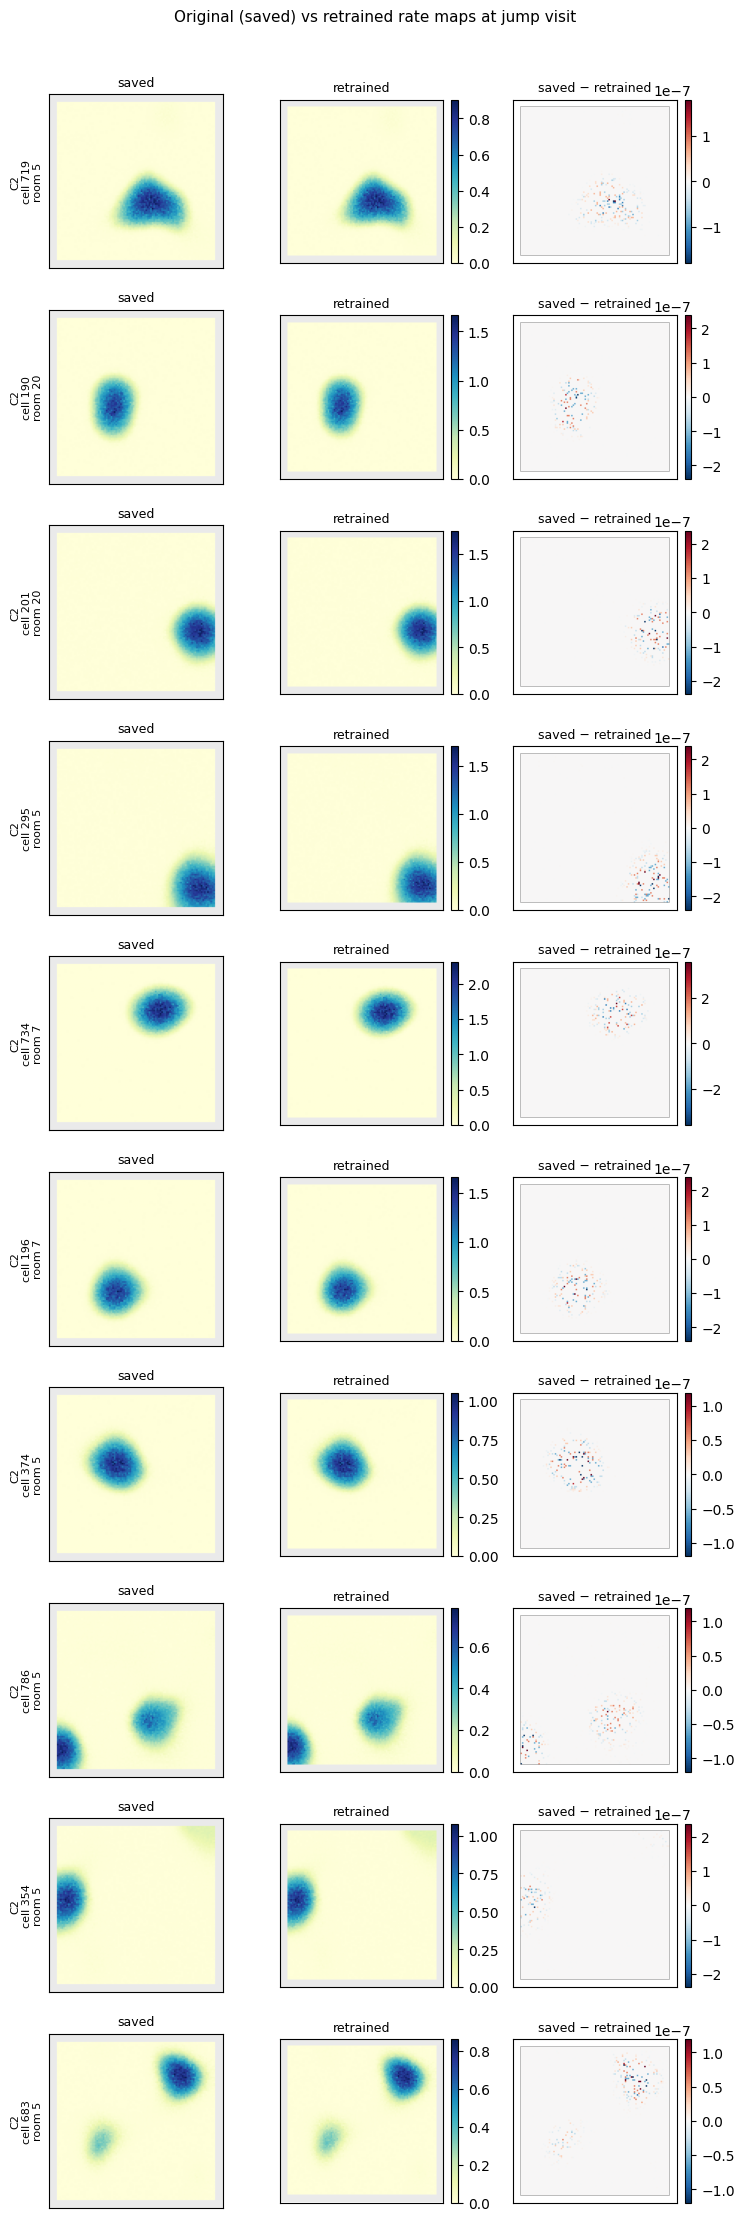

,cell_idx,room_id,jump_cycle,pearson_r,mse
0,719,5,1,1.0,5.738555e-17
1,190,20,1,1.0,9.792840e-17
2,201,20,1,1.0,1.167951e-16
3,295,5,1,1.0,1.475894e-16
4,734,7,1,1.0,2.071477e-16
5,196,7,1,1.0,9.892881e-17
6,374,5,1,1.0,4.179284e-17
7,786,5,1,1.0,3.218564e-17
8,354,5,1,1.0,4.157691e-17
9,683,5,1,1.0,3.470102e-17


In [7]:
def spatial_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.ravel()
    b = b.ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    return float(np.corrcoef(a[mask], b[mask])[0, 1])


def spatial_mse(a: np.ndarray, b: np.ndarray) -> float:
    diff = a - b
    mask = np.isfinite(diff)
    if not mask.any():
        return np.nan
    return float(np.mean(diff[mask] ** 2))


from mpl_toolkits.axes_grid1 import make_axes_locatable

summary_rows = []
cmap = _gaussian_evolution_cmap()
n_targets = len(targets)
fig, axes = plt.subplots(
    n_targets,
    3,
    figsize=(7.5, 2.2 * n_targets),
    squeeze=False,
)

for i, t in enumerate(targets.itertuples()):
    key = (int(t.visit_idx), int(t.cell_idx))
    original = ratemaps_by_visit.get(key)
    retrained_rm = retrained.get((int(t.cell_idx), int(t.room_id)))
    if original is None or retrained_rm is None:
        continue

    original = np.asarray(original, dtype=np.float64)
    retrained_rm = np.asarray(retrained_rm, dtype=np.float64)
    diff = original - retrained_rm

    vmin = float(np.nanmin([original, retrained_rm]))
    vmax = float(np.nanmax([original, retrained_rm]))
    if vmin == vmax:
        vmax = vmin + 1e-6

    diff_vmax = float(np.nanmax(np.abs(diff)))
    if diff_vmax == 0:
        diff_vmax = 1e-6

    for j, (arr, label) in enumerate([(original, "saved"), (retrained_rm, "retrained")]):
        ax = axes[i, j]
        im_rate = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    ax_diff = axes[i, 2]
    im_diff = ax_diff.imshow(diff, cmap="RdBu_r", vmin=-diff_vmax, vmax=diff_vmax)
    ax_diff.set_title("saved − retrained", fontsize=9)
    ax_diff.set_xticks([])
    ax_diff.set_yticks([])

    rate_cax = make_axes_locatable(axes[i, 1]).append_axes("right", size="4%", pad=0.08)
    fig.colorbar(im_rate, cax=rate_cax)

    diff_cax = make_axes_locatable(ax_diff).append_axes("right", size="4%", pad=0.08)
    fig.colorbar(im_diff, cax=diff_cax)

    axes[i, 0].set_ylabel(
        f"C{int(t.jump_cycle) + 1}\ncell {t.cell_idx}\nroom {t.room_id}",
        fontsize=8,
    )

    summary_rows.append(
        {
            "cell_idx": int(t.cell_idx),
            "room_id": int(t.room_id),
            "jump_cycle": int(t.jump_cycle),
            "pearson_r": spatial_corr(original, retrained_rm),
            "mse": spatial_mse(original, retrained_rm),
        }
    )

fig.suptitle("Original (saved) vs retrained rate maps at jump visit", fontsize=11,y=1.01)
fig.subplots_adjust(wspace=0.35)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(summary_rows)
summary